# Feels Like Temperature 验证
读取官方测试数据，运行修改后的算法，并与预期和原始输出进行比较。

## 环境准备

In [ ]:
%matplotlib inline

import sys
import warnings
import numpy as np
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt

# 设置警告过滤器
warnings.filterwarnings("ignore", category=FutureWarning, module="xarray")
warnings.filterwarnings("ignore", category=UserWarning, message="pkg_resources is deprecated")

# 设置工作空间根目录并添加到 sys.path
workspace_root = Path(r"d:/workspace/improver")
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

from temperature.src.feels_like_temperature import calculate_feels_like_temperature

## 路径配置

In [2]:
input_dir = workspace_root / "temperature" / "test_data" / "feels_like_temp_data"
normalized_dir = input_dir / "normalized_meb6d"
normalized_dir.mkdir(parents=True, exist_ok=True)
output_dir = normalized_dir

# 各输入文件的路径映射
paths = {
    "temperature": input_dir / "20181121T1200Z-PT0012H00M-temperature_at_screen_level.nc",      # 温度数据
    "wind_speed": input_dir / "20181121T1200Z-PT0012H00M-wind_speed_at_10m.nc",                 # 风速数据
    "relative_humidity": input_dir / "20181121T1200Z-PT0012H00M-relative_humidity_at_screen_level.nc",  # 相对湿度数据
    "pressure": input_dir / "20181121T1200Z-PT0012H00M-pressure_at_mean_sea_level.nc",          # 气压数据
    "expected": input_dir / "kgo.nc",                                                           # 标准答案（KGO）
    "original": input_dir / "original_feels_like_temp_result.nc",                               # 原始算法结果
    "original_cli": input_dir / "original_cli_result.nc",                                       # 原始CLI结果
}

## 数据预处理

将原始 NetCDF 升维为 meteva_base 标准六维（`member, level, time, dtime, lat, lon`）。
预处理逻辑内联在下方单元格中，**不依赖** `tools/` 目录；输出写入 `normalized_meb6d/` 供后续读取。

In [3]:
from temperature.utils.utils import rebuild_to_meb_griddata

try:
    from pyproj import CRS, Transformer
except ImportError:
    CRS = None
    Transformer = None

_REQUIRED_DIMS = ("member", "level", "time", "dtime", "lat", "lon")
_DEFAULT_ATTRS = {
    "units": None,
    "model": None,
    "dtime_units": "hour",
    "level_type": "isobaric",
    "time_type": "UT",
    "time_bounds": [0, 0],
}


def _is_nearly_uniform_step(values: np.ndarray, rtol: float = 5e-3, atol: float = 1e-8) -> bool:
    arr = np.asarray(values, dtype=np.float64)
    if arr.ndim != 1 or arr.size < 3:
        return True
    diffs = np.diff(arr)
    if not np.all(np.isfinite(diffs)):
        return False
    return np.allclose(diffs, diffs[0], rtol=rtol, atol=atol)


def _fill_required_attrs(attrs: dict) -> dict:
    filled = dict(attrs)
    for key, default in _DEFAULT_ATTRS.items():
        if key not in filled or filled[key] in (None, ""):
            filled[key] = default
    return filled


def _make_netcdf_safe_attrs(attrs: dict) -> dict:
    return {key: ("" if value is None else value) for key, value in attrs.items()}


def _find_grid_mapping_name(dataset: xr.Dataset, data: xr.DataArray) -> str | None:
    gm = data.attrs.get("grid_mapping")
    if isinstance(gm, str) and gm in dataset.variables:
        return gm
    for var_name in dataset.data_vars:
        cand = dataset[var_name].attrs.get("grid_mapping")
        if isinstance(cand, str) and cand in dataset.variables:
            return cand
    return None


def _build_transformer(dataset: xr.Dataset, data: xr.DataArray):
    if CRS is None or Transformer is None:
        warnings.warn("pyproj 不可用，跳过投影坐标转经纬度。")
        return None
    grid_mapping_name = _find_grid_mapping_name(dataset, data)
    if grid_mapping_name is None:
        return None
    attrs = dict(dataset[grid_mapping_name].attrs)
    try:
        if attrs.get("crs_wkt"):
            src_crs = CRS.from_wkt(attrs["crs_wkt"])
        else:
            src_crs = CRS.from_cf(attrs)
        return Transformer.from_crs(src_crs, CRS.from_epsg(4326), always_xy=True)
    except Exception as exc:
        warnings.warn(f"无法解析 grid_mapping={grid_mapping_name}，跳过坐标转换: {exc}")
        return None


def _convert_projection_to_latlon(data: xr.DataArray, dataset: xr.Dataset):
    dims = tuple(data.dims)
    if "projection_y_coordinate" not in dims or "projection_x_coordinate" not in dims:
        return data, False
    y_coord = data.coords.get("projection_y_coordinate")
    x_coord = data.coords.get("projection_x_coordinate")
    if y_coord is None or x_coord is None or y_coord.ndim != 1 or x_coord.ndim != 1:
        return data, False
    transformer = _build_transformer(dataset, data)
    if transformer is None:
        return data, False

    x_vals = np.asarray(x_coord.values, dtype=np.float64)
    y_vals = np.asarray(y_coord.values, dtype=np.float64)
    xx, yy = np.meshgrid(x_vals, y_vals)
    lon2d, lat2d = transformer.transform(xx, yy)
    lat_1d = np.nanmean(lat2d, axis=1)
    lon_1d = np.nanmean(lon2d, axis=0)

    out = data.rename({"projection_y_coordinate": "lat", "projection_x_coordinate": "lon"})
    out = out.assign_coords(lat=("lat", lat_1d.astype(np.float64)), lon=("lon", lon_1d.astype(np.float64)))

    if not (_is_nearly_uniform_step(lat_1d) and _is_nearly_uniform_step(lon_1d)):
        lat_lin = np.linspace(float(lat_1d[0]), float(lat_1d[-1]), lat_1d.size, dtype=np.float64)
        lon_lin = np.linspace(float(lon_1d[0]), float(lon_1d[-1]), lon_1d.size, dtype=np.float64)
        out = out.interp(lat=lat_lin, lon=lon_lin, method="linear")
        out = out.assign_coords(lat=("lat", lat_lin), lon=("lon", lon_lin))
        warnings.warn("投影转经纬度后坐标非等距，已重采样到规则经纬网。")

    out_attrs = dict(out.attrs)
    out_attrs.pop("grid_mapping", None)
    out.attrs = out_attrs
    return out, True


def _normalize_dims(data: xr.DataArray, dataset: xr.Dataset) -> xr.DataArray:
    data, _ = _convert_projection_to_latlon(data, dataset)
    dims = tuple(data.dims)

    rename_map = {}
    if "latitude" in dims and "lat" not in dims:
        rename_map["latitude"] = "lat"
    if "longitude" in dims and "lon" not in dims:
        rename_map["longitude"] = "lon"
    if "y" in dims and "lat" not in dims:
        rename_map["y"] = "lat"
    if "x" in dims and "lon" not in dims:
        rename_map["x"] = "lon"
    if rename_map:
        data = data.rename(rename_map)
        dims = tuple(data.dims)

    if data.ndim == 2:
        y_name = "lat" if "lat" in dims else dims[-2]
        x_name = "lon" if "lon" in dims else dims[-1]
        data = data.transpose(y_name, x_name)
        if y_name != "lat" or x_name != "lon":
            data = data.rename({y_name: "lat", x_name: "lon"})
    elif data.ndim == 3:
        level_name = "level" if "level" in dims else dims[0]
        y_name = "lat" if "lat" in dims else dims[-2]
        x_name = "lon" if "lon" in dims else dims[-1]
        data = data.transpose(level_name, y_name, x_name)
        rename_3d = {}
        if level_name != "level":
            rename_3d[level_name] = "level"
        if y_name != "lat":
            rename_3d[y_name] = "lat"
        if x_name != "lon":
            rename_3d[x_name] = "lon"
        if rename_3d:
            data = data.rename(rename_3d)
    elif data.ndim == 6 and set(dims) == set(_REQUIRED_DIMS):
        data = data.transpose(*_REQUIRED_DIMS)
    else:
        raise ValueError(f"暂不支持维度 {dims}（ndim={data.ndim}）。请先整理为 2D、3D 或标准 6D。")

    if "member" not in data.dims:
        data = data.expand_dims({"member": ["data0"]})
    if "level" not in data.dims:
        data = data.expand_dims({"level": [0.0]})
    if "time" not in data.dims:
        data = data.expand_dims({"time": [np.datetime64("1970-01-01T00:00:00")]})
    if "dtime" not in data.dims:
        data = data.expand_dims({"dtime": [0]})

    data = data.transpose(*_REQUIRED_DIMS)
    data.attrs = _fill_required_attrs(dict(data.attrs))
    return rebuild_to_meb_griddata(np.asarray(data.values, dtype=np.float32), data)


def preprocess_to_meb6d(src_path: Path, dst_path: Path, var_name: str) -> None:
    """将单个 nc 文件预处理为标准六维并写出。"""
    ds = xr.open_dataset(src_path, decode_timedelta=False)
    try:
        if var_name not in ds.data_vars:
            raise ValueError(f"变量 {var_name} 不存在，可选: {list(ds.data_vars)}")
        data = ds[var_name].copy()
        merged_attrs = dict(data.attrs)
        if merged_attrs.get("model") in (None, "") and "mosg__model_configuration" in ds.attrs:
            merged_attrs["model"] = ds.attrs.get("mosg__model_configuration")
        data.attrs = _fill_required_attrs(merged_attrs)

        normalized = _normalize_dims(data, ds).astype(np.float32, copy=False)
        normalized.name = var_name
        normalized.attrs = _make_netcdf_safe_attrs(dict(normalized.attrs))

        dst_path.parent.mkdir(parents=True, exist_ok=True)
        normalized.to_dataset(name=normalized.name).to_netcdf(dst_path)
    finally:
        ds.close()


def detect_var_name(src_path: Path, candidates: list[str]) -> str:
    with xr.open_dataset(src_path, engine="netcdf4", decode_timedelta=False) as ds:
        for name in candidates:
            if name in ds.data_vars:
                return name
        data_vars = list(ds.data_vars)
        if len(data_vars) == 1:
            return data_vars[0]
    raise ValueError(f"无法为 {src_path.name} 检测到变量名，候选: {candidates}")

In [4]:
normalize_targets = {
    "temperature": ["air_temperature", "temperature_at_screen_level"],
    "wind_speed": ["wind_speed", "wind_speed_at_10m"],
    "relative_humidity": ["relative_humidity", "relative_humidity_at_screen_level"],
    "pressure": ["air_pressure_at_sea_level", "pressure_at_mean_sea_level", "surface_air_pressure"],
    "expected": ["feels_like_temperature", "air_temperature", "kgo"],
    "original": ["feels_like_temperature", "air_temperature", "original_algorithm_result"],
}

processed_count = 0
for key, candidates in normalize_targets.items():
    src = paths[key]
    dst = normalized_dir / src.name
    
    #如果文件已存在且非空，默认跳过
    if (not dst.exists()) or dst.stat().st_size == 0:
        print(f"正在处理: {src.name}")
        try:
            var_name = detect_var_name(src, candidates)
            preprocess_to_meb6d(src, dst, var_name)
            processed_count += 1
            print(f"✓ 已预处理: {src.name}")
        except Exception as exc:
            print(f"✗ 处理失败 {src.name}: {exc}")

print(f"✓ 预处理完成，共处理 {processed_count} 个文件")

✓ 预处理完成，共处理 0 个文件


## 数据加载函数定义

In [5]:
def open_preferred_dataset(raw_path: Path):
    """优先读取 normalized_meb6d 目录下数据，不存在则回退原始文件。"""
    preferred = normalized_dir / raw_path.name
    if preferred.exists() and preferred.stat().st_size > 0:
        return xr.open_dataset(preferred, engine="netcdf4", decode_timedelta=False)
    return xr.open_dataset(raw_path, engine="netcdf4", decode_timedelta=False)


def select_var(ds, preferred_names):
    for name in preferred_names:
        if name in ds.data_vars:
            return ds[name]
    data_vars = list(ds.data_vars)
    if len(data_vars) == 1:
        return ds[data_vars[0]]
    raise ValueError(f"Cannot determine variable. Candidates: {data_vars}")

## 数据转换函数定义

In [6]:
def to_2d(a) -> np.ndarray:
    """
    将多维数组转换为2D数组
    
    处理逻辑：
    1. 先压缩所有维度为1的轴
    2. 如果维度仍大于2，取第一个维度
    
    参数：
        a: 输入数组（numpy数组或xarray DataArray）
        
    返回：
        2D numpy数组
    """
    arr = np.asarray(a).squeeze()  # 压缩维度为1的轴
    
    # 如果维度仍大于2，取第一个维度
    while arr.ndim > 2:
        arr = arr[0]
    
    if arr.ndim != 2:
        raise ValueError(f"期望2D数组, 实际维度: {arr.ndim}")
    
    return arr

## 加载数据

In [7]:
# 加载所有数据集
t_ds = open_preferred_dataset(paths["temperature"])      # 温度数据集
w_ds = open_preferred_dataset(paths["wind_speed"])       # 风速数据集
rh_ds = open_preferred_dataset(paths["relative_humidity"])  # 相对湿度数据集
p_ds = open_preferred_dataset(paths["pressure"])         # 气压数据集
expected_ds = open_preferred_dataset(paths["expected"])  # 标准答案数据集
original_ds = open_preferred_dataset(paths["original"])  # 原始算法结果数据集
original_cli_ds = open_preferred_dataset(paths["original_cli"])  # 原始CLI结果数据集

# 从各数据集中提取相应的变量
t = select_var(t_ds, ["air_temperature", "temperature_at_screen_level"])
w = select_var(w_ds, ["wind_speed", "wind_speed_at_10m"])
rh = select_var(rh_ds, ["relative_humidity", "relative_humidity_at_screen_level"])
p = select_var(p_ds, ["air_pressure_at_sea_level", "pressure_at_mean_sea_level", "surface_air_pressure"])

# 提取参考结果
expected = select_var(expected_ds, ["feels_like_temperature", "air_temperature", "kgo"])
original = select_var(original_ds, ["feels_like_temperature", "air_temperature", "original_algorithm_result"])
original_cli = select_var(original_cli_ds, ["feels_like_temperature", "air_temperature", "data"])

## 调用calculate_feels_like_temperature函数计算体感温度

In [8]:
#计算体感温度
modified = calculate_feels_like_temperature(t, w, rh, p)

In [9]:
#数据转换（转为2D用于可视化）
try:
    modified_2d = to_2d(modified)
    expected_2d = to_2d(expected)
    original_2d = to_2d(original)
    original_cli_2d = to_2d(original_cli)
    
    print(f"✓ 体感温度（修改后）形状: {modified_2d.shape}")
    print(f"✓ 标准答案（KGO）形状: {expected_2d.shape}")
    print(f"✓ 原始算法结果形状: {original_2d.shape}")
    print(f"✓ 原始CLI结果形状: {original_cli_2d.shape}")
except Exception as e:
    print(f"✗ 数据转换失败: {e}")

# 准备用于可视化的辅助数据
aux_data = {
    "Temperature": to_2d(t),           # 温度（2D）
    "Wind Speed": to_2d(w),            # 风速（2D）
    "Relative Humidity": to_2d(rh),    # 相对湿度（2D）
    "Pressure": to_2d(p),              # 气压（2D）
}

✓ 体感温度（修改后）形状: (49, 53)
✓ 标准答案（KGO）形状: (49, 53)
✓ 原始算法结果形状: (49, 53)
✓ 原始CLI结果形状: (49, 53)


## 输入数据图

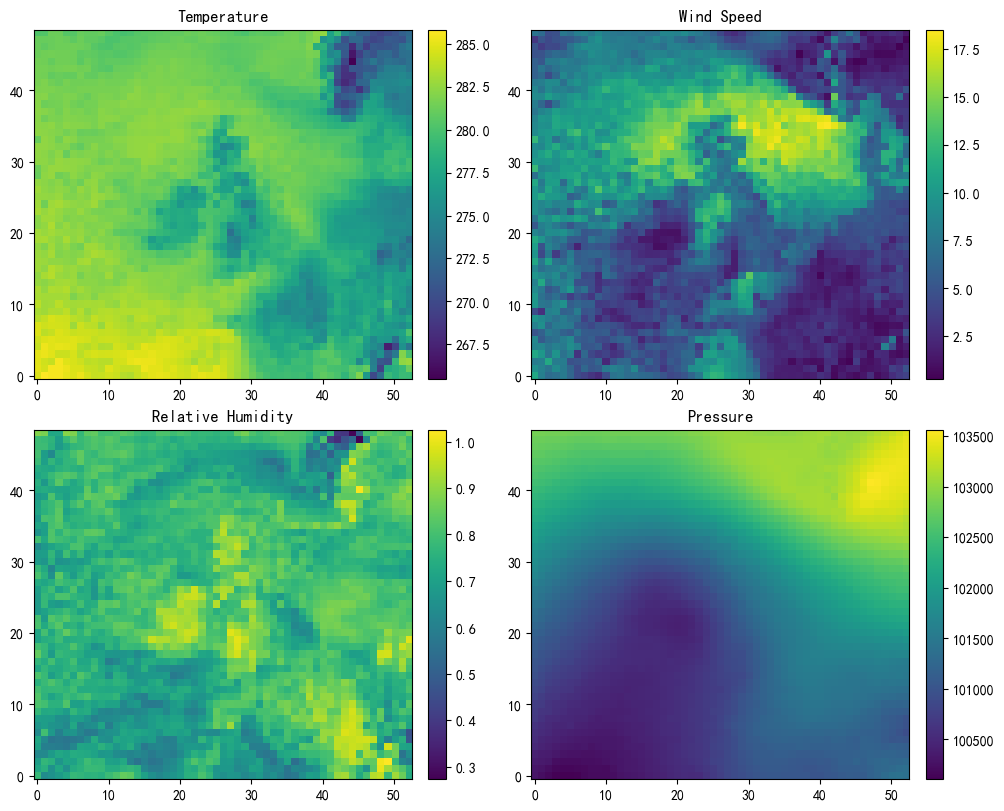

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
for ax, (title, data) in zip(axes.ravel(), aux_data.items()):
    im = ax.imshow(data, origin="lower", cmap="viridis")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

## 结果对比图

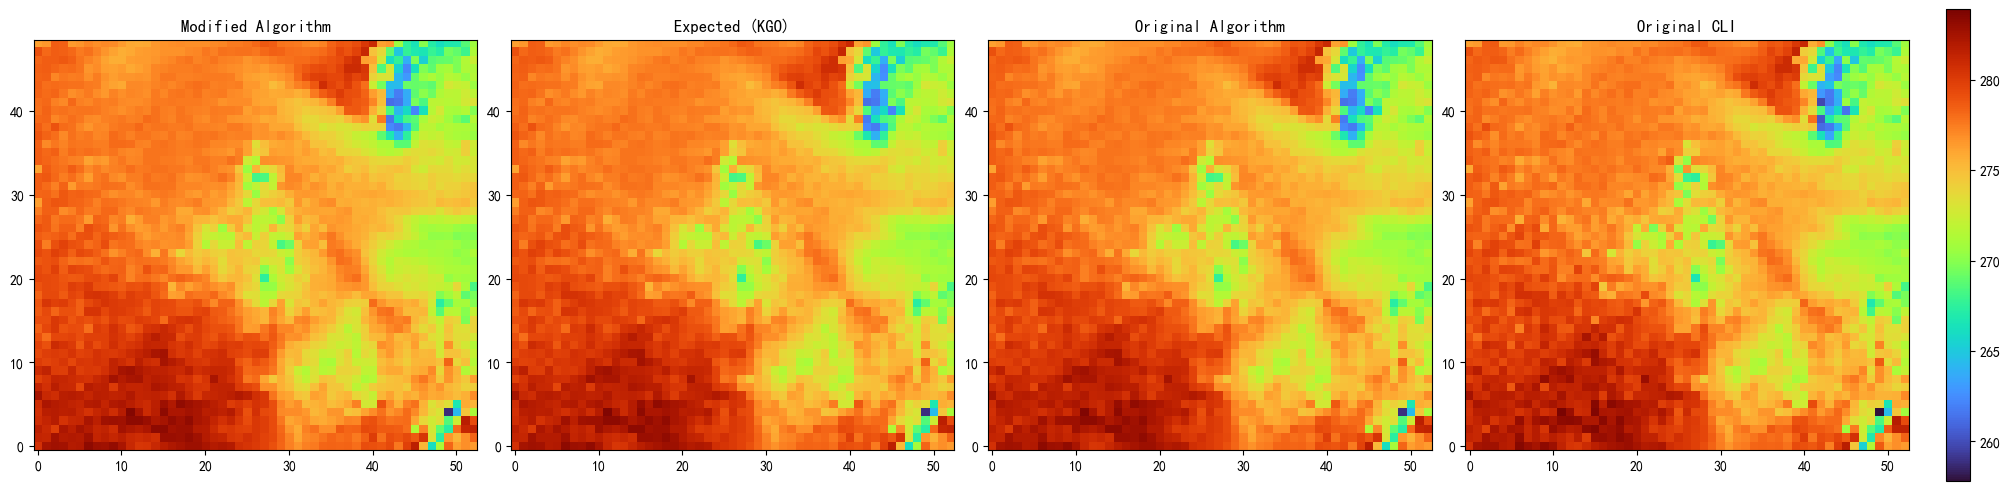

In [11]:
vmin = np.nanmin([modified_2d, expected_2d, original_2d, original_cli_2d])
vmax = np.nanmax([modified_2d, expected_2d, original_2d, original_cli_2d])

fig, axes = plt.subplots(1, 4, figsize=(20, 4.8), constrained_layout=True)

im0 = axes[0].imshow(modified_2d, origin="lower", cmap="turbo", vmin=vmin, vmax=vmax)
axes[0].set_title("Modified Algorithm")

im1 = axes[1].imshow(expected_2d, origin="lower", cmap="turbo", vmin=vmin, vmax=vmax)
axes[1].set_title("Expected (KGO)")

im2 = axes[2].imshow(original_2d, origin="lower", cmap="turbo", vmin=vmin, vmax=vmax)
axes[2].set_title("Original Algorithm")

im3 = axes[3].imshow(original_cli_2d, origin="lower", cmap="turbo", vmin=vmin, vmax=vmax)
axes[3].set_title("Original CLI")

fig.colorbar(im3, ax=axes, fraction=0.025, pad=0.02)
plt.show()



## CLI 应用示例（PowerShell）

请在 `d:/workspace/improver` 下手动执行（官方测试数据）：

```powershell
python -m temperature.cli.der_feel_like_temp
```

输出文件：`temperature/test_data/feels_like_temp_data/normalized_meb6d/cli_feels_like_temp_result.nc`（路径在脚本底部 `__main__` 段配置）。

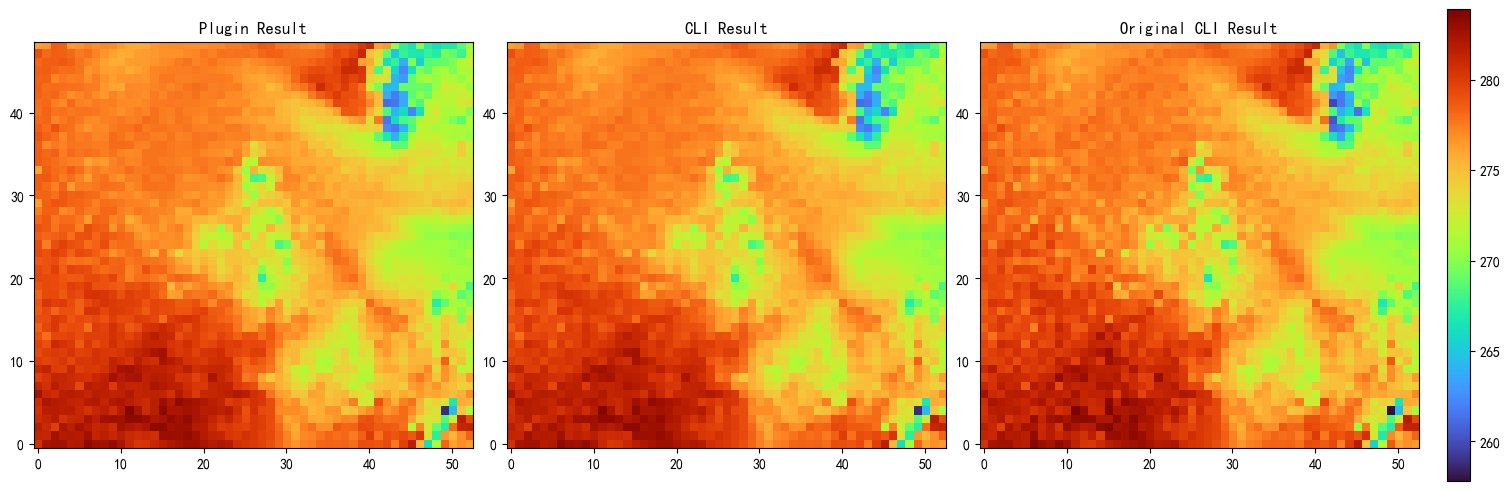

In [12]:
cli_result_path = output_dir / "cli_feels_like_temp_result.nc"
if (not cli_result_path.exists()) or cli_result_path.stat().st_size == 0:
    raise FileNotFoundError(f"CLI result is missing or empty: {cli_result_path}")

cli_ds = xr.open_dataset(cli_result_path, engine="netcdf4")
cli_result = select_var(cli_ds, ["feels_like_temperature", "air_temperature", "data"])
cli_2d = to_2d(cli_result)

vmin_cli = np.nanmin([modified_2d, cli_2d, original_cli_2d])
vmax_cli = np.nanmax([modified_2d, cli_2d, original_cli_2d])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)

im0 = axes[0].imshow(modified_2d, origin="lower", cmap="turbo", vmin=vmin_cli, vmax=vmax_cli)
axes[0].set_title("Plugin Result")

im1 = axes[1].imshow(cli_2d, origin="lower", cmap="turbo", vmin=vmin_cli, vmax=vmax_cli)
axes[1].set_title("CLI Result")

im2 = axes[2].imshow(original_cli_2d, origin="lower", cmap="turbo", vmin=vmin_cli, vmax=vmax_cli)
axes[2].set_title("Original CLI Result")

fig.colorbar(im2, ax=axes, fraction=0.03, pad=0.02)
plt.show()


